# **Data preparation**

In [1]:
# data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
# !wget $data

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('./02-regression/data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [5]:
df.head(3)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350


In [6]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [7]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [8]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [9]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# **EDA**
- Exploratory Data Analysis

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


**Long-tail distribution**

<Axes: xlabel='msrp', ylabel='Count'>

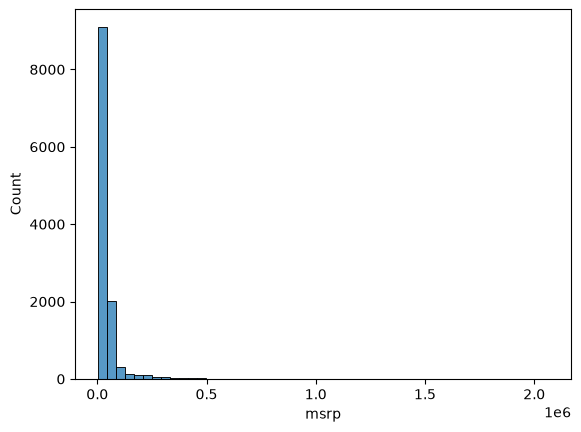

In [12]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

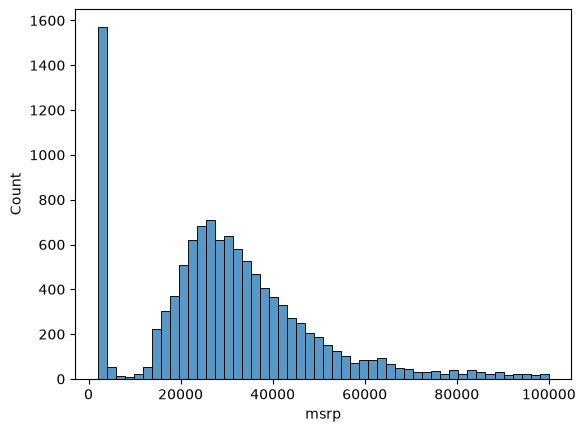

In [13]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [14]:
np.log([0, 1, 10, 100, 1000])

/tmp/ipykernel_3596/3864374125.py:1: RuntimeWarning: divide by zero encountered in log
  np.log([0, 1, 10, 100, 1000])


array([      -inf, 0.        , 2.30258509, 4.60517019, 6.90775528])

In [15]:
np.log([0 + 1, 1 + 1, 10 + 1, 100 + 1, 1000 + 1])

array([0.        , 0.69314718, 2.39789527, 4.61512052, 6.90875478])

In [16]:
np.log1p([0, 1, 10, 100, 1000])

array([0.        , 0.69314718, 2.39789527, 4.61512052, 6.90875478])

In [17]:
price_logs = np.log1p(df.msrp)

**Normal distribution**

<Axes: xlabel='msrp', ylabel='Count'>

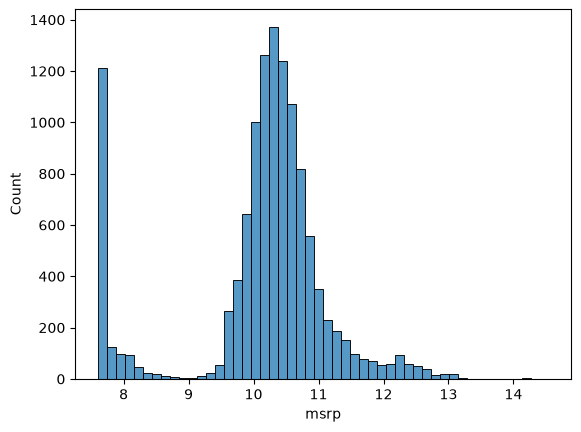

In [18]:
sns.histplot(price_logs, bins=50)

In [19]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# **Validation Framework**
- Train, Validation, and Test

In [20]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = int(n * 0.6)

n, n_train + n_val + n_test

(11914, 11912)

- Rounding Problem

In [21]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

n, n_train + n_val + n_test

(11914, 11914)

In [22]:
n, n_train, n_val, n_test

(11914, 7150, 2382, 2382)

In [23]:
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val + n_test]
df_train = df.iloc[n_val + n_test:]

In [24]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,porsche,cayenne,2016,premium_unleaded_(required),570.0,8.0,automatic,all_wheel_drive,4.0,"crossover,luxury,high-performance",midsize,4dr_suv,21,14,1715,157300
2378,porsche,cayenne,2016,diesel,240.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury,diesel",midsize,4dr_suv,29,20,1715,62300
2379,porsche,cayenne,2017,premium_unleaded_(required),520.0,8.0,automatic,all_wheel_drive,4.0,"crossover,luxury,performance",midsize,4dr_suv,21,14,1715,116500
2380,porsche,cayenne,2017,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,24,18,1715,59600


In [25]:
df_train[df_train.make == 'porche'] # no porsche in the training set

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp


In [26]:
df.iloc[[4, 2, 5, 1, 0]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135


In [27]:
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

In [28]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [29]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [30]:
df_train.head(3)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795


In [31]:
df_val.head(3)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2779,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
3708,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
4794,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775


In [32]:
df_test.head(3)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11195,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
673,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
11270,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120


In [33]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [34]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [35]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

# **Linear Regression**

## **$$g(X) ≈ y$$**

simplified: $g(x_i) ≈ y_i$

In [36]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [37]:
xi = [453, 11, 86]

$g(x_i) = w_0 + w_1\cdot x_{i1} + w_2\cdot x_{i2} + w_3\cdot x_{i3}$\
$g(x_i) = w_0 + \sum_{j=1}^n w_j \cdot x_{ij}$

In [38]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [39]:
def linear_regression(xi):
    n = len(xi)
    pred = w0
    for j in range(n):
        pred += w[j] * xi[j]
    return pred

In [40]:
linear_regression(xi)

12.312

In [41]:
7.17 + 0.01*453 + 0.04*11 + 0.002*86

12.312

In [42]:
np.expm1(12.312)

np.float64(222347.2221101062)

In [43]:
np.log1p(222347.2221101062)

np.float64(12.312)

$g(x_i) = w_0 + \sum_{j=1}^nx_{ij}\cdot w_j \\ \longrightarrow g(x_i) = w_0 + x_i^T\cdot w$

In [44]:
def dot(xi, w):
    assert len(xi) == len(w)
    n = len(xi)
    res = 0.0
    for j in range(n):
        res += xi[j] * w[j]
    return res

In [45]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [46]:
linear_regression(xi)

12.312000000000001

**Fictional feature**

In [47]:
w_new = [w0] + w
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [48]:
linear_regression(xi)

12.312

In [49]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)

In [50]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

$Xw≈y$

In [51]:
def linear_regression(X):
    return X.dot(w_new)

In [52]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

In [53]:
np.expm1(linear_regression(X))

array([237992.82334859, 768348.51018973, 222347.22211011])

$Xw ≈ y$
- X is square matrix, invertible:
    - $X⁻¹Xw = X⁻¹y\\
        Iw = X⁻¹y\\
        w = X⁻¹y$
- X is rectangular matrix:
    - $XᵀXw = Xᵀy \rightarrow$ (XᵀX is **Gram matrix**, usually invertible)
    - $(XᵀX)⁻¹XᵀXw = (XᵀX)⁻¹Xᵀy\\
    w = (XᵀX)⁻¹Xᵀy \rightarrow$ (**Normal equation**)

In [54]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)

$X^TX$

In [55]:
XTX = X.T.dot(X) # Gram matrix

$(X^TX)^{-1}$

In [56]:
XTX_inv = np.linalg.inv(XTX)

In [57]:
XTX.dot(XTX_inv).round(1)

array([[ 1.,  0.,  0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [58]:
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

$w = (X^TX)^{-1}X^Ty$

In [59]:
w_full = XTX_inv.dot(X.T).dot(y) # normal equation

In [60]:
w_full

array([0.26190562, 3.06101252, 0.03696909])

In [61]:
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

In [62]:
w0 = w_full[0]
w = w_full[1:]

In [63]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

In [64]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [65]:
train_linear_regression(X, y)

(np.float64(300.06776692555627),
 array([-0.22774253, -2.5769413 , -0.02301206]))

# **Baseline model**

In [66]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [67]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [68]:
X_train = df_train[base].values # baseline features

In [69]:
w0, w = train_linear_regression(X_train, y_train)

In [70]:
w0, w

(np.float64(nan), array([nan, nan, nan, nan, nan]))

In [71]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [72]:
X_train = df_train[base].fillna(0).values # new baseline features without null values

$g(x_i) = w_0 + x_{i1}·w_1 + x_{i2}·w_2 \quad$      ($x_{i1}$ is missing)
    $\\\quad\quad\quad = w_0 +   0·w_1 + x_{i2}·w_2$
     $\\\quad\quad\quad= w_0 +  \quad\quad\quad\quad       x_{i2}·w_2$

In [73]:
w0, w = train_linear_regression(X_train, y_train) # baseline model

In [74]:
w0, w

(np.float64(7.927257388070037),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [75]:
y_pred = w0 + X_train.dot(w) # linear regression function

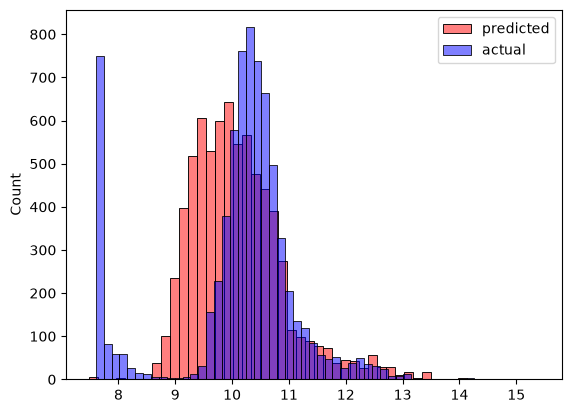

In [76]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50, legend=True, label='predicted')
sns.histplot(y_train, color='blue', alpha=0.5, bins=50, legend=True, label='actual')
plt.legend()

# **RMSE**
- Root mean squared error

$RMSE = sqrt( (1/m) · Σ (g(xi) - yi)² )$

```python
y_pred:  10     9     11    10
y:        9     9     10.5  11.5
```

$g(x_i) - y_i$

```latex
10 - 9    =  1
 9 - 9    =  0
11 - 10.5 =  0.5
10 - 11.5 = -1.5
```

$\left (g(x_i) - y_i\right)^2$

```latex
1   → 1
0   → 0
0.5 → 0.25
-1.5 → 2.25
```

- it makes negative and positive errors comparable - otherwise they would cancel each other out
- it penalizes larger errors more

$\frac{1}{4}\cdot\sum_{i=1}^4\left (g(x_i) - y_i\right)^2$

```python
(1 + 0 + 0.25 + 2.25) / 4 = 0.875
```

$\sqrt{\frac{1}{4}\cdot\sum_{i=1}^4\left (g(x_i) - y_i\right)^2}$

```python
sqrt(0.875) ≈ 0.93
```

In [82]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [81]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [83]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

validation:

In [84]:
X_train = df_train[base].fillna(0).values

In [85]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [86]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w) # linear regression function
rmse(y_val, y_pred)

np.float64(0.7616530991301627)

# **Feature engineering**

In [92]:
df_train.year.max()

np.int64(2017)

In [93]:
2017 - df_train.year

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [94]:
def prepare_X(df):
    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [96]:
X_train = prepare_X(df_train)

**The function should not modify the data**

In [99]:
del df_train['age']

In [101]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [105]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w) # linear regression

rmse(y_val, y_pred)

np.float64(0.5172055461058327)

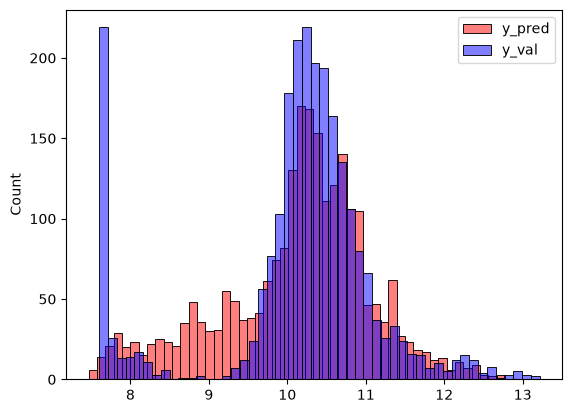

In [106]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50, legend=True, label='y_pred')
sns.histplot(y_val, color='blue', alpha=0.5, bins=50, legend=True, label='y_val')
plt.legend()

# **Categorical variables**

In [108]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [109]:
df.number_of_doors.unique()

array([ 2.,  4.,  3., nan])

| number_of_doors | num_doors_2 | num_doors_3 | num_doors_4 |
|---|---|---|---|
| 2 | 1 | 0 | 0 |
| 3 | 0 | 1 | 0 |
| 4 | 0 | 0 | 1 |

In [112]:
df_train.number_of_doors == 2

0        True
1       False
2       False
3       False
4       False
        ...  
7145     True
7146     True
7147    False
7148    False
7149    False
Name: number_of_doors, Length: 7150, dtype: bool

In [113]:
(df_train.number_of_doors == 2).astype(int)

0       1
1       0
2       0
3       0
4       0
       ..
7145    1
7146    1
7147    0
7148    0
7149    0
Name: number_of_doors, Length: 7150, dtype: int64

In [136]:
for v in [2, 3, 4]:
    df_train["num_doors_%s" % v] = (df_train.number_of_doors == v).astype('int')

In [137]:
df_train[['number_of_doors', 'num_doors_2', 'num_doors_3', 'num_doors_4']]

,number_of_doors,num_doors_2,num_doors_3,num_doors_4
0,2.0,1,0,0
1,4.0,0,0,1
2,4.0,0,0,1
3,3.0,0,1,0
4,4.0,0,0,1
...,...,...,...,...
7145,2.0,1,0,0
7146,2.0,1,0,0
7147,4.0,0,0,1
7148,4.0,0,0,1


In [138]:
del df_train['num_doors_2']
del df_train['num_doors_3']
del df_train['num_doors_4']

In [139]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [140]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5157995641501902)

In [146]:
df.make.nunique()

48

In [147]:
makes = list(df.make.value_counts().head().index)

In [148]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)
        
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [149]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5076038849556633)

In [150]:
df.nunique()

make                   48
model                 914
year                   28
engine_fuel_type       10
engine_hp             356
engine_cylinders        9
transmission_type       5
driven_wheels           4
number_of_doors         3
market_category        71
vehicle_size            3
vehicle_style          16
highway_mpg            59
city_mpg               69
popularity             48
msrp                 6049
dtype: int64

In [154]:
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

In [156]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'hatchback',
  'luxury,performance'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

**One-Hot encoding**

In [157]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)


    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))
        
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [158]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(28.478764165331985)

In [162]:
w0, w

(np.float64(-2577834190335544.0),
 array([-1.02773048e-01,  2.31827513e+00, -7.06462786e-01, -2.64609447e-01,
        -1.31137567e-03, -1.06250839e+00,  2.84940121e+02,  2.81474399e+02,
         2.81218916e+02, -1.08144069e+00,  1.40232523e-01, -4.89483488e+00,
         1.06571840e+00, -2.70853832e+00,  1.08342939e+01,  1.24195251e+01,
         1.25591158e+01,  1.46144067e+01,  1.63346129e+01,  1.42848783e+15,
         1.42848783e+15,  1.42848783e+15,  1.42848783e+15,  1.42848783e+15,
         1.14934636e+15,  1.14934636e+15,  1.14934636e+15,  1.14934636e+15,
         6.42217042e-01, -4.97977066e-01, -1.12731142e+00, -2.60326289e+00,
         1.72945918e+00, -3.55994515e+01, -3.41552488e+01, -3.32618156e+01,
        -4.85492239e-02,  5.44797374e-02,  1.78241160e-01,  3.41906701e-01,
        -1.64412078e-01]))